In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


In [2]:
import warnings
warnings.filterwarnings("ignore")

from transformers.utils import logging
logging.set_verbosity_error()

train_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

In [3]:
train_df.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [4]:
train_df.shape

(2000, 8)

# **EXPLORATORY DATA ANALYSIS**

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


In [6]:
train_df.isnull().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

In [7]:
train_df['prompt'].duplicated().sum()

np.int64(242)

In [8]:
train_df = train_df.drop_duplicates(
    subset=["prompt", "A", "B", "C", "D", "E", "answer"]
).reset_index(drop=True)

In [9]:
train_df.shape

(1817, 8)

In [10]:
train_df['answer'].value_counts()

answer
B    442
C    423
D    329
A    328
E    295
Name: count, dtype: int64

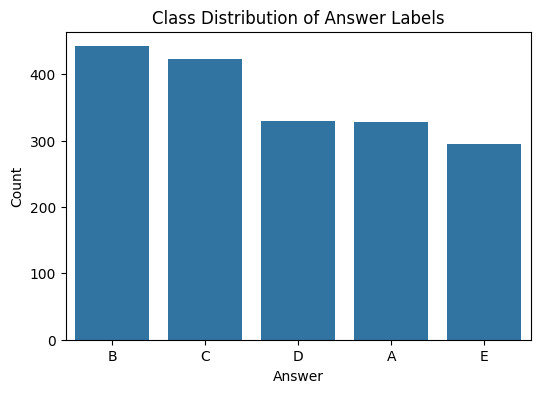

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

plt.figure(figsize=(6, 4))
sns.countplot(
    x='answer',
    data=train_df,
    order=train_df['answer'].value_counts().index
)

plt.title("Class Distribution of Answer Labels")
plt.xlabel("Answer")
plt.ylabel("Count")
plt.show()

# **FEATURE ENGINEERING**

In [12]:
import re

train_df = train_df.drop(columns=['id'])

def clean_text(text):
    text = text.lower()
    
    text = re.sub(r'[^a-z0-9\s]', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

text_columns = ['prompt', 'A', 'B', 'C', 'D', 'E']

for col in text_columns:
    train_df[col] = train_df[col].apply(clean_text)

In [13]:
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['answer']
)
train_data.head()

,prompt,A,B,C,D,E,answer
1547,which of the following is correct what is the ...,far ultraviolet light is absorbed effectively ...,far ultraviolet light is absorbed effectively ...,far ultraviolet light is absorbed effectively ...,far ultraviolet light is absorbed effectively ...,far ultraviolet light is absorbed effectively ...,B
339,determine the correct option what is the relat...,the amplitude of a sound wave is related to it...,the amplitude of a sound wave is directly prop...,the amplitude of a sound wave is not related t...,the amplitude of a sound wave is not related t...,the amplitude of a sound wave is inversely rel...,A
35,determine the correct option what is the purpo...,to emit a cone of askaryan radiation that trav...,to emit a cone of bremsstrahlung radiation tha...,to emit a cone of cherenkov light that travers...,to emit a cone of cherenkov light that travers...,to emit a cone of bremsstrahlung radiation tha...,D
956,pick the best possible answer what is the reas...,the sun appears yellowish due to a reflection ...,the longer wavelengths of light such as red an...,the sun appears yellowish due to the scatterin...,the sun emits a yellow light due to its own sp...,the atmosphere absorbs the shorter wavelengths...,B
1776,choose the correct answer which of the followi...,the blocking temperature of an antiferromagnet...,the blocking temperature of an antiferromagnet...,the blocking temperature of an antiferromagnet...,the blocking temperature of an antiferromagnet...,the blocking temperature of an antiferromagnet...,D


In [14]:
def expand_dataset(df, is_train=True):
    expanded_data = []
    options = ['A', 'B', 'C', 'D', 'E']

    for question_id, (_, row) in enumerate(df.iterrows()):

        for option in options:

            sample = {
                "question_id": question_id,
                "option": option,
                "prompt": row["prompt"],
                "text": row[option]
            }

            if is_train:
                sample["label"] = 1 if option == row["answer"] else 0

            expanded_data.append(sample)

    return pd.DataFrame(expanded_data)

train_binary = expand_dataset(train_data, is_train=True)
val_binary = expand_dataset(val_data, is_train=True)

train_binary["text"] = (train_binary["prompt"] + " " + train_binary["text"])

val_binary["text"] = (val_binary["prompt"] + " " + val_binary["text"])

print(train_binary.shape)
print(val_binary.shape)

(7265, 5)
(1820, 5)


In [15]:
train_binary.head()

,question_id,option,prompt,text,label
0,0,A,which of the following is correct what is the ...,which of the following is correct what is the ...,0
1,0,B,which of the following is correct what is the ...,which of the following is correct what is the ...,1
2,0,C,which of the following is correct what is the ...,which of the following is correct what is the ...,0
3,0,D,which of the following is correct what is the ...,which of the following is correct what is the ...,0
4,0,E,which of the following is correct what is the ...,which of the following is correct what is the ...,0


In [16]:
train_binary["label"].value_counts()

label
0    5812
1    1453
Name: count, dtype: int64

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=False,      
    max_features=30000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train = vectorizer.fit_transform(train_binary['text'])
X_val = vectorizer.transform(val_binary['text'])

y_train = train_binary['label']
y_val = val_binary['label']

# **BASELINE MODEL LOGISTIC REGRESSION**

In [18]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42,max_iter=1000)

lr_model.fit(X_train, y_train)

y_prob = lr_model.predict_proba(X_val)

correct_prob = y_prob[:, 1]

val_binary['probability'] = correct_prob

In [19]:
def get_top3_predictions(df):
    top3_predictions = []

    for question_id, group in df.groupby("question_id"):

        # Sort options by predicted probability
        group = group.sort_values("probability", ascending=False)

        # Get the top 3 option labels
        top3 = group["option"].head(3).tolist()

        # Get the correct answer
        true_answer = group.loc[group["label"] == 1, "option"].iloc[0]

        top3_predictions.append({
            "question_id": question_id,
            "true_answer": true_answer,
            "predicted_answer": top3[0],   
            "top3_predictions": top3
        })

    return pd.DataFrame(top3_predictions)

results_df = get_top3_predictions(val_binary)

results_df.head()

,question_id,true_answer,predicted_answer,top3_predictions
0,0,A,A,"[A, B, D]"
1,1,A,A,"[A, E, C]"
2,2,E,E,"[E, B, D]"
3,3,D,D,"[D, B, E]"
4,4,D,D,"[D, A, C]"


In [20]:
def map_at_3(true_answers, predicted_lists):
    scores = []

    for true, preds in zip(true_answers, predicted_lists):

        if true in preds:
            rank = preds.index(true) + 1
            scores.append(1 / rank)
        else:
            scores.append(0)

    return sum(scores) / len(scores)

map3 = map_at_3(results_df["true_answer"],results_df["top3_predictions"])

print(f"MAP@3: {map3:.4f}")

MAP@3: 0.9872


In [21]:
from sklearn.metrics import accuracy_score, f1_score

# Accuracy
accuracy = round(
    accuracy_score(
        results_df["true_answer"],
        results_df["predicted_answer"]
    ),
    3
)

# Macro F1 Score
macro_f1 = round(
    f1_score(
        results_df["true_answer"],
        results_df["predicted_answer"],
        average="macro"
    ),
    3
)

print(f"Accuracy      : {accuracy}")
print(f"Macro F1 Score: {macro_f1}")

Accuracy      : 0.981
Macro F1 Score: 0.98


**W&B - LOGISTIC REGRESSION**

In [22]:
from kaggle_secrets import UserSecretsClient
import wandb

user_secrets = UserSecretsClient()
wandb_api = user_secrets.get_secret("WANDB_API_KEY")

wandb.login(key=wandb_api)

wandb.init(
    project="23f3004120-t22026",
    name="tfidf-logistic-regression"
)

wandb.config.update({
    "model": "TF-IDF + Logistic Regression",
    "max_features": 30000,
    "ngram_range": (1,2),
    "sublinear_tf": True,
    "max_iter": 1000
})

wandb.log({
    "accuracy": accuracy,
    "macro_f1": macro_f1,
    "validation_map3": map3,
    "kaggle_map3": 0.75
})

wandb.finish()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 23f3004120 (23f3004120-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


accuracy,▁
kaggle_map3,▁
macro_f1,▁
validation_map3,▁
accuracy,0.981
kaggle_map3,0.75
macro_f1,0.98
validation_map3,0.98718


# **MODEL-1 ANN**

In [23]:
mlp_vectorizer = TfidfVectorizer(
    lowercase=False,
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_mlp = mlp_vectorizer.fit_transform(train_binary["text"])
X_val_mlp = mlp_vectorizer.transform(val_binary["text"])


In [24]:
import joblib

joblib.dump(mlp_vectorizer, "mlp_vectorizer.pkl")

['mlp_vectorizer.pkl']

In [25]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Convert sparse TF-IDF matrices to dense arrays
X_train_tensor = torch.FloatTensor(X_train_mlp.toarray())
X_val_tensor = torch.FloatTensor(X_val_mlp.toarray())

# Labels
y_train_tensor = torch.LongTensor(train_binary["label"].values)
y_val_tensor = torch.LongTensor(val_binary["label"].values)

batch_size = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)

val_loader = DataLoader(val_dataset,batch_size=batch_size,shuffle=False)

X_train_tensor.shape

torch.Size([7265, 10000])

In [26]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [27]:
input_dim = X_train_tensor.shape[1]
num_classes = len(np.unique(train_binary["label"]))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mlp_model = MLPClassifier(
    input_dim=input_dim,
    num_classes=num_classes
).to(device)

print(mlp_model)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    mlp_model.parameters(),
    lr=1e-3
)

MLPClassifier(
  (network): Sequential(
    (0): Linear(in_features=10000, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [28]:
wandb.init(
    project="23f3004120-t22026",
    name="tfidf-mlp"
)

wandb.config.update({
    "model": "TF-IDF + MLP (PyTorch)",
    "max_features": 10000,
    "ngram_range": (1, 2),
    "sublinear_tf": True,
    "hidden_layers": [256, 128],
    "dropout": 0.3,
    "batch_size": 32,
    "epochs": 10,
    "learning_rate": 1e-3,
    "optimizer": "Adam",
    "loss_function": "CrossEntropyLoss"
})

In [29]:
num_epochs = 10

for epoch in range(num_epochs):

    mlp_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = mlp_model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    wandb.log({
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "learning_rate": optimizer.param_groups[0]["lr"]
    })

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Loss: {running_loss/len(train_loader):.4f} | "
        f"Train Acc: {train_acc:.4f}"
    )

Epoch 1/10 | Loss: 0.4588 | Train Acc: 0.8066
Epoch 2/10 | Loss: 0.2316 | Train Acc: 0.9013
Epoch 3/10 | Loss: 0.1547 | Train Acc: 0.9350
Epoch 4/10 | Loss: 0.1135 | Train Acc: 0.9515
Epoch 5/10 | Loss: 0.0927 | Train Acc: 0.9590
Epoch 6/10 | Loss: 0.0832 | Train Acc: 0.9645
Epoch 7/10 | Loss: 0.0708 | Train Acc: 0.9704
Epoch 8/10 | Loss: 0.0678 | Train Acc: 0.9703
Epoch 9/10 | Loss: 0.0575 | Train Acc: 0.9751
Epoch 10/10 | Loss: 0.0540 | Train Acc: 0.9745


In [30]:
torch.save(mlp_model.state_dict(), "mlp_model.pth")

In [31]:
mlp_model.eval()

predictions = []
probabilities = []

with torch.no_grad():

    for X_batch, _ in val_loader:

        X_batch = X_batch.to(device)

        logits = mlp_model(X_batch)

        probs = torch.softmax(logits, dim=1)

        preds = torch.argmax(probs, dim=1)

        predictions.extend(preds.cpu().numpy())
        probabilities.extend(probs[:, 1].cpu().numpy())

In [32]:
accuracy = accuracy_score(val_binary["label"],predictions)
macro_f1 = f1_score(val_binary["label"],predictions,average="macro")
mlp_results = val_binary.copy()

mlp_results["probability"] = probabilities

mlp_results_df = get_top3_predictions(mlp_results)

map3 = map_at_3(mlp_results_df["true_answer"],mlp_results_df["top3_predictions"])

print(f"Accuracy : {accuracy:.4f}")
print(f"Macro F1 : {macro_f1:.4f}")
print(f"MAP@3: {map3:.4f}")

Accuracy : 0.9659
Macro F1 : 0.9451
MAP@3: 0.9721


**W&B - MLP**

In [33]:
wandb.log({
    "accuracy": accuracy,
    "macro_f1": macro_f1,
    "validation_map3": map3
})

wandb.finish()

accuracy,▁
learning_rate,▁▁▁▁▁▁▁▁▁▁
macro_f1,▁
train_accuracy,▁▅▆▇▇█████
train_loss,█▄▃▂▂▂▁▁▁▁
validation_map3,▁
accuracy,0.96593
learning_rate,0.001
macro_f1,0.94505
train_accuracy,0.97454
train_loss,0.05397


# **MODEL-2 BERT**

In [34]:
# Create copies for the BERT model
bert_train = train_data.copy()
bert_val = val_data.copy()

def create_bert_input(row):
    return (
        f"Question: {row['prompt']} "
        f"[SEP] A: {row['A']} "
        f"[SEP] B: {row['B']} "
        f"[SEP] C: {row['C']} "
        f"[SEP] D: {row['D']} "
        f"[SEP] E: {row['E']}"
    )

bert_train["text"] = bert_train.apply(create_bert_input, axis=1)
bert_val["text"] = bert_val.apply(create_bert_input, axis=1)

In [35]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

bert_train["label"] = label_encoder.fit_transform(bert_train["answer"])
bert_val["label"] = label_encoder.transform(bert_val["answer"])

print(label_encoder.classes_)

['A' 'B' 'C' 'D' 'E']


In [36]:
print(bert_train["text"].iloc[0])
print()
print("Label:", bert_train["label"].iloc[0])

Question: which of the following is correct what is the reason that it is nearly impossible to see light emitted at the lyman alpha transition wavelength from a star farther than a few hundred light years from earth from the following choices [SEP] A: far ultraviolet light is absorbed effectively by the charged components of the ism including atomic helium which has a typical absorption wavelength of about 121 5 nanometers the lyman alpha transition [SEP] B: far ultraviolet light is absorbed effectively by the neutral components of the ism including atomic hydrogen which has a typical absorption wavelength of about 121 5 nanometers the lyman alpha transition [SEP] C: far ultraviolet light is absorbed effectively by the charged components of the ism including atomic hydrogen which has a typical absorption wavelength of about 121 5 nanometers the lyman alpha transition [SEP] D: far ultraviolet light is absorbed effectively by the neutral components of the ism including atomic helium whic

In [37]:
from transformers import BertTokenizer

MODEL_NAME = "bert-base-uncased"

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

MAX_LENGTH = 512

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [38]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    bert_train[["text", "label"]]
)

val_dataset = Dataset.from_pandas(
    bert_val[["text", "label"]]
)

train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/1453 [00:00<?, ? examples/s]

Map:   0%|          | 0/364 [00:00<?, ? examples/s]

In [39]:
train_dataset = train_dataset.remove_columns(["text"])
val_dataset = val_dataset.remove_columns(["text"])

train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

val_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

print(train_dataset[0])

{'label': tensor(1), 'input_ids': tensor([  101,  3160,  1024,  2029,  1997,  1996,  2206,  2003,  6149,  2054,
         2003,  1996,  3114,  2008,  2009,  2003,  3053,  5263,  2000,  2156,
         2422, 22627,  2012,  1996, 27587,  6541,  6653, 19934,  2013,  1037,
         2732,  8736,  2084,  1037,  2261,  3634,  2422,  2086,  2013,  3011,
         2013,  1996,  2206,  9804,   102,  1037,  1024,  2521, 26299,  2422,
         2003,  9063,  6464,  2011,  1996,  5338,  6177,  1997,  1996,  2003,
         2213,  2164,  9593, 22764,  2029,  2038,  1037,  5171, 16326, 19934,
         1997,  2055, 12606,  1019, 28991, 22828,  2015,  1996, 27587,  6541,
         6653,   102,  1038,  1024,  2521, 26299,  2422,  2003,  9063,  6464,
         2011,  1996,  8699,  6177,  1997,  1996,  2003,  2213,  2164,  9593,
         9732,  2029,  2038,  1037,  5171, 16326, 19934,  1997,  2055, 12606,
         1019, 28991, 22828,  2015,  1996, 27587,  6541,  6653,   102,  1039,
         1024,  2521, 26299,  

In [40]:
from transformers import BertForSequenceClassification

bert_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=5
)

print(bert_model.config)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3",
    "4": "LABEL_4"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_2": 2,
    "LABEL_3": 3,
    "LABEL_4": 4
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}



In [41]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    macro_f1 = f1_score(labels, predictions, average="macro")

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1
    }

    Input X
   (512×768)
       │
       ▼
    Q = XWq
    K = XWk
    V = XWv

   (512×768)
       │
       ▼
    Reshape

    Q, K, V

  (512×12×64)
       │
       ▼
  Each Head

  Q (512×64)

  K (512×64)

  V (512×64)
       │
       ▼
      QKᵀ
       │
       ▼
    512×512
       │
       ▼
     Scale
       │
       ▼
Apply Attention Mask 
       │
       ▼   
    Softmax
       │
       ▼
Attention × V
       │
       ▼
    512×64
       │
       ▼
Concatenate
       │
       ▼
    512×768
       │
       ▼
Output Linear Layer
Weights: 768 × 768
       │
       ▼
    512×768
       │
       ▼
Residual (Skip Connection)

Attention Output + Original Input X
       │
       ▼
    512×768
       │
       ▼
Layer Normalization
       │
       ▼
    512×768
       │
       ▼
Feed Forward Network

Dense Layer
Weights: 768 × 3072
       │
       ▼
   512 × 3072
       │
       ▼
     GELU
       │
       ▼
   512 × 3072
       │
       ▼
Dense Layer
Weights: 3072 × 768
       │
       ▼
   512 × 768
       │
       ▼
Residual (Skip Connection)

FFN Output + FFN Input
(the FFN input is the output of the first LayerNorm)
       │
       ▼
    512×768
       │
       ▼
Layer Normalization
       │
       ▼
    512×768
       ↓
Final Output of Transformer Layer
       ↓
Passed as input to the next Transformer Layer
Input Text
       ↓
12 Transformer Layers
       ↓
  Final Output

   512 × 768
       ↓
  Take [CLS]
       ↓
     1 × 768
       ↓
Classification Head

Dense

768 → 5
     ↓
  Logits

   1 × 5
     ↓
   Softmax
      ↓
Probabilities
      ↓
Predicted Option


In [42]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./bert_results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=4,

    weight_decay=0.01,

    warmup_ratio=0.1,

    load_best_model_at_end=True,

    metric_for_best_model="macro_f1",
    greater_is_better=True,

    logging_steps=20,

    report_to="wandb",

    save_total_limit=1,

    seed=42
)

In [43]:
from transformers import Trainer

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

{'loss': '3.21', 'grad_norm': '6.548', 'learning_rate': '2e-05', 'epoch': '0.4348'}
{'loss': '2.979', 'grad_norm': '10.92', 'learning_rate': '1.758e-05', 'epoch': '0.8696'}
{'eval_loss': '2.681', 'eval_accuracy': '0.4808', 'eval_macro_f1': '0.41', 'eval_runtime': '6.558', 'eval_samples_per_second': '55.5', 'eval_steps_per_second': '1.83', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '2.599', 'grad_norm': '11.26', 'learning_rate': '1.515e-05', 'epoch': '1.304'}
{'loss': '2.191', 'grad_norm': '12.21', 'learning_rate': '1.273e-05', 'epoch': '1.739'}
{'eval_loss': '1.622', 'eval_accuracy': '0.8791', 'eval_macro_f1': '0.8755', 'eval_runtime': '6.884', 'eval_samples_per_second': '52.88', 'eval_steps_per_second': '1.743', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '1.797', 'grad_norm': '13.98', 'learning_rate': '1.03e-05', 'epoch': '2.174'}
{'loss': '1.391', 'grad_norm': '11.93', 'learning_rate': '7.879e-06', 'epoch': '2.609'}
{'eval_loss': '0.9162', 'eval_accuracy': '0.9945', 'eval_macro_f1': '0.9946', 'eval_runtime': '6.908', 'eval_samples_per_second': '52.7', 'eval_steps_per_second': '1.737', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '1.12', 'grad_norm': '11.21', 'learning_rate': '5.455e-06', 'epoch': '3.043'}
{'loss': '0.9049', 'grad_norm': '7.063', 'learning_rate': '3.03e-06', 'epoch': '3.478'}
{'loss': '0.801', 'grad_norm': '9.522', 'learning_rate': '6.061e-07', 'epoch': '3.913'}
{'eval_loss': '0.6813', 'eval_accuracy': '0.9945', 'eval_macro_f1': '0.9946', 'eval_runtime': '6.891', 'eval_samples_per_second': '52.82', 'eval_steps_per_second': '1.741', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '354.4', 'train_samples_per_second': '16.4', 'train_steps_per_second': '0.519', 'train_loss': '1.864', 'epoch': '4'}


TrainOutput(global_step=184, training_loss=1.864135584105616, metrics={'train_runtime': 354.374, 'train_samples_per_second': 16.401, 'train_steps_per_second': 0.519, 'train_loss': 1.864135584105616, 'epoch': 4.0})

In [44]:
trainer.save_model("./bert_mcq_model")
tokenizer.save_pretrained("./bert_mcq_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./bert_mcq_model/tokenizer_config.json', './bert_mcq_model/tokenizer.json')

In [45]:
predictions = trainer.predict(val_dataset)

logits = predictions.predictions

print(logits.shape)

(364, 5)


In [46]:
from scipy.special import softmax

probabilities = softmax(logits, axis=1)

top3_indices = np.argsort(probabilities, axis=1)[:, ::-1][:, :3]

top3_predictions = [
    list(label_encoder.inverse_transform(row))
    for row in top3_indices
]

map3 = map_at_3(
    bert_val["answer"].tolist(),
    top3_predictions
)

print(f"Validation MAP@3: {map3:.4f}")

Validation MAP@3: 0.9968


**W&B - BERT**

In [47]:
wandb.init(
    project="23f3004120-t22026",
    name="bert-base-uncased",
    tags=["bert", "pretrained"],
    config={
        "model": "bert-base-uncased",
        "epochs": 4,
        "learning_rate": 2e-5,
        "batch_size": 16,
        "max_length": 512,
        "optimizer": "AdamW"
    }
)

wandb.log({
    "accuracy": predictions.metrics["test_accuracy"],
    "macro_f1": predictions.metrics["test_macro_f1"],
    "validation_map3": map3
})

wandb.finish()

eval/accuracy,▁▆██
eval/loss,█▄▂▁
eval/macro_f1,▁▇██
eval/runtime,▁███
eval/samples_per_second,█▁▁▁
eval/steps_per_second,█▁▁▁
test/accuracy,▁
test/loss,▁
test/macro_f1,▁
test/runtime,▁
+7,...


accuracy,▁
macro_f1,▁
validation_map3,▁
accuracy,0.99451
macro_f1,0.99462
validation_map3,0.99679


# **MODEL-3 RAG**

In [48]:
knowledge_docs = []

for _, row in train_data.iterrows():

    document = f"""
Question:
{row['prompt']}

Option A:
{row['A']}

Option B:
{row['B']}

Option C:
{row['C']}

Option D:
{row['D']}

Option E:
{row['E']}

Correct Answer:
{row['answer']}
"""

    knowledge_docs.append(document.strip())

print(f"Knowledge Base Size: {len(knowledge_docs)} documents")

Knowledge Base Size: 1453 documents


In [49]:
from sentence_transformers import SentenceTransformer

# Load embedding model
embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

# Generate embeddings
knowledge_embeddings = embedding_model.encode(
    knowledge_docs,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Embedding Shape:", knowledge_embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/46 [00:00<?, ?it/s]

Embedding Shape: (1453, 384)


In [50]:
!pip install faiss-gpu -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.2/135.2 MB 12.3 MB/s eta 0:00:0000:0100:01


In [51]:
import faiss

# Get embedding dimension
embedding_dim = knowledge_embeddings.shape[1]

# Create FAISS index
faiss_index = faiss.IndexFlatIP(embedding_dim)

# Add embeddings
faiss_index.add(
    knowledge_embeddings.astype(np.float32)
)

print("Number of indexed documents:", faiss_index.ntotal)

Number of indexed documents: 1453


In [52]:
def retrieve_similar_questions(query_text, top_k=5):
    """
    Retrieve top_k most similar questions from the knowledge base.
    """

    # Embed query
    query_embedding = embedding_model.encode(
        [query_text],
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype(np.float32)

    # Search FAISS
    similarity_scores, indices = faiss_index.search(query_embedding, top_k)

    return similarity_scores[0], indices[0]

In [53]:
from sentence_transformers import CrossEncoder

cross_encoder = CrossEncoder(
    "cross-encoder/ms-marco-MiniLM-L-6-v2"
)

print("CrossEncoder loaded successfully!")

def rerank_documents(query_text, retrieved_indices):
    """
    Re-rank retrieved documents using CrossEncoder.
    """

    pairs = [
        (query_text, knowledge_docs[idx])
        for idx in retrieved_indices
    ]

    scores = cross_encoder.predict(pairs)

    reranked = sorted(
        zip(retrieved_indices, scores),
        key=lambda x: x[1],
        reverse=True
    )

    return reranked

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

CrossEncoder loaded successfully!


In [54]:
from transformers import pipeline

classifier = pipeline(
    task="zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0      # GPU
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [55]:
def build_rag_prompt(query_text, top_k=5):
    """
    Retrieve the best supporting document and
    build the augmented prompt for BART.
    """

    # Retrieve Top-K documents
    _, retrieved_indices = retrieve_similar_questions(
        query_text,
        top_k=top_k
    )

    # Re-rank retrieved documents
    reranked_docs = rerank_documents(
        query_text,
        retrieved_indices
    )

    # Best retrieved document
    best_idx, best_score = reranked_docs[0]

    best_document = knowledge_docs[best_idx]

    # Build RAG prompt
    augmented_text = (
        f"Context:\n"
        f"{best_document}\n\n"
        f"Question:\n"
        f"{query_text}"
    )
    return augmented_text

In [56]:
sample_question = val_data.iloc[0]["prompt"]

prompt = build_rag_prompt(sample_question)

print(prompt)

Context:
Question:
which of the following is correct what is the relationship between the cauchy momentum equation and the navier stokes equation based on the given context

Option A:
the navier stokes equation can be derived from the cauchy momentum equation by specifying the stress tensor through a constitutive relation expressing the shear tensor in terms of viscosity and fluid velocity and assuming constant density and viscosity

Option B:
the navier stokes equation is a simplified version of the cauchy momentum equation that only applies to situations with constant density and viscosity

Option C:
the navier stokes equation is a special case of the cauchy momentum equation which is a more general equation that applies to all non relativistic momentum conservation situations

Option D:
the cauchy momentum equation and the navier stokes equation are completely unrelated and cannot be used interchangeably in any situation

Option E:
the cauchy momentum equation is a special case of t

In [57]:
# Select one validation sample
sample = val_data.iloc[0]

# Build RAG prompt
augmented_text = build_rag_prompt(sample["prompt"])

# Candidate labels are the option texts
candidate_labels = [
    sample["A"],
    sample["B"],
    sample["C"],
    sample["D"],
    sample["E"]
]

# Run BART
result = classifier(
    augmented_text,
    candidate_labels=candidate_labels,
    multi_label=False
)

print("Ranked option texts:")
for label, score in zip(result["labels"], result["scores"]):
    print(f"{score:.4f}  {label}")

Ranked option texts:
0.2371  the navier stokes equation can be derived from the cauchy momentum equation by specifying the stress tensor through a constitutive relation expressing the shear tensor in terms of viscosity and fluid velocity and assuming constant density and viscosity
0.2180  the navier stokes equation is a simplified version of the cauchy momentum equation that only applies to situations with constant density and viscosity
0.2002  the cauchy momentum equation and the navier stokes equation are completely unrelated and cannot be used interchangeably in any situation
0.1785  the navier stokes equation is a special case of the cauchy momentum equation which is a more general equation that applies to all non relativistic momentum conservation situations
0.1662  the cauchy momentum equation is a special case of the navier stokes equation which is a more general equation that applies to all non relativistic momentum conservation situations


In [58]:
def predict_with_bart(row, top_k=5):
    """
    Predict Top-3 answer letters using:
    Retrieval -> CrossEncoder -> Context Augmentation -> BART
    """

    # Build RAG prompt
    augmented_text = build_rag_prompt(row["prompt"], top_k=top_k)

    # Candidate labels are the option texts
    candidate_labels = [
        row["A"],
        row["B"],
        row["C"],
        row["D"],
        row["E"]
    ]

    # Run BART
    result = classifier(
        augmented_text,
        candidate_labels=candidate_labels,
        multi_label=False
    )

    # Map option text back to letter
    option_map = {
        row["A"]: "A",
        row["B"]: "B",
        row["C"]: "C",
        row["D"]: "D",
        row["E"]: "E"
    }

    # Return Top-3 letters
    top3 = [
        option_map[label]
        for label in result["labels"][:3]
    ]

    return top3

In [59]:
val_predictions = []

for _, row in val_data.iterrows():
    pred = predict_with_bart(row)
    val_predictions.append(pred)

print("Prediction completed!")

true_answers = val_data["answer"].tolist()

score = map_at_3(
    true_answers,
    val_predictions
)

print(f"Validation MAP@3: {score:.4f}")

Prediction completed!
Validation MAP@3: 0.5472


In [60]:
# Top-1 prediction
y_pred = [pred[0] for pred in val_predictions]

# Ground truth
y_true = val_data["answer"].tolist()

accuracy = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")

print(f"Accuracy : {accuracy:.4f}")
print(f"Macro F1 : {macro_f1:.4f}")
print(f"MAP@3     : {score:.4f}")

Accuracy : 0.3407
Macro F1 : 0.3370
MAP@3     : 0.5472


**W&B - RAG**

In [61]:
wandb.init(
    project="23f3004120-t22026",
    name="rag-faiss-crossencoder-bart",
    config={
        "model": "RAG",
        "retriever": "SentenceTransformer",
        "vector_store": "FAISS",
        "reranker": "CrossEncoder",
        "generator": "facebook/bart-large-mnli",
        "top_k": 5
    }
)

wandb.log({
    "accuracy": accuracy,
    "macro_f1": macro_f1,
    "validation_map3": score
})

wandb.finish()

accuracy,▁
macro_f1,▁
validation_map3,▁
accuracy,0.34066
macro_f1,0.33704
validation_map3,0.54716


# **SUBMISSION**

In [62]:
# Drop id column (keep a copy separately if needed for submission)
test_ids = test_df['id']

test_df = test_df.drop(columns=['id'])

# Clean text
for col in text_columns:
    test_df[col] = test_df[col].apply(clean_text)

# Expand each question into 5 prompt-option pairs
test_binary = expand_dataset(test_df, is_train=False)

# Create text column (same as training)
test_binary["text"] = (
    test_binary["prompt"] + " " + test_binary["text"]
)

# Transform using the already-fitted TF-IDF vectorizer
X_test = vectorizer.transform(test_binary["text"])

# Predict probabilities
test_prob = lr_model.predict_proba(X_test)[:, 1]

# Store probabilities
test_binary["probability"] = test_prob

In [63]:
def get_top3_test_predictions(df):
    predictions = []

    for question_id, group in df.groupby("question_id"):

        group = group.sort_values("probability", ascending=False)

        top3 = group["option"].head(3).tolist()

        predictions.append({
            "question_id": question_id,
            "prediction": " ".join(top3)
        })

    return pd.DataFrame(predictions)

submission = get_top3_test_predictions(test_binary)

submission["id"] = test_ids.values

submission = submission[["id", "prediction"]]

submission.to_csv("submission.csv", index=False)
submission.head()

,id,prediction
0,1,A E C
1,2,B E A
2,3,B E D
3,4,E C A
4,5,C A B
